<div style="text-align: center; font-weight: bold; font-size: 150%">Projet 1 - SHAP: Understanding the Functioning of an ML-based (XGBoost)</div><br>
<div style="text-align: center; font-size: 100%">Yayrale AKIBODE</div><br>
<div style="text-align: center; font-size: 100%">Professeur: Stéphane CHRETIEN</div><br>
<div style="text-align: center; font-size: 100%">M2 MALIA - Université Lumière Lyon 2</div>

Ce travail se base sur le notebook [ici](https://colab.research.google.com/drive/1rTvXrrIHfMS3MoL-ssiSAPMRORLAkXOW?usp=sharing).

<div style="text-align: center; font-weight: bold; font-size: 125%">1. Méthode SHAP</div><br>

Les Shapley Values permettent d'analyser les contributions des variables à la prédiction d'une observation. L'explication du modèle s'écrit comme une fonction linéaire ci-dessous.

\begin{equation}
g(z') = \phi_0 + \sum_{i=1}^{M}\phi_i z'_i
\end{equation}

- $z' \in \{0,1\}^M $, M est le nombre de variables.
- $\phi_0 = \mathbb{E}[g(Z')]$  est la prédiction moyenne du modèle.
- $\phi_i $ est la contribution de la variable *i* à la prédiction de l'observation $z'$.

La contribution d'une variable s'écrit comme ci-dessous.

\begin{equation}
\phi_i = \sum_{S \subseteq F \\ \{i\}} \frac{\mid S\mid! (\mid F\mid - \mid S\mid - 1)!}{\mid F\mid !} [f_{S \bigcup \{i\}}(x_{S \bigcup \{i\}}) - f_S(x_S)]
\end{equation}

- $f$ représente la fonction du modèle.
- $F$ est l'ensemble de toutes les variables.
- $S$ est un sous-ensemble de $F$
- $\mid S \mid$ est le cardinald de $S$.

Les valeurs de Shapley respectent les propriétés suivantes:

- Efficience : la somme des contributions des variables est égale à la différence entre la prédiction pour une observation et la prédiction moyenne.

- Symétrie : deux variables qui ont le même effet sur la prédiction reçoivent la même contribution.

- Additivité : pour un modèle composé de plusieurs sous-modèles (comme le bagging), la valeur de Shapley globale est la somme des contributions de chaque modèle.

- Dummy (Nullité) : une variable qui n’influence pas la prédiction a une contribution nulle.

<div style="text-align: center; font-weight: bold; font-size: 125%">2. Étude de cas du notebook original: Bipolar Disease Crisis Prediction</div><br>

Dans le notebook original, les données manipulées sont des données sur les troubles bipolaires.

Le trouble bipolaire, anciennement appelé psychose maniaco-dépressive, est une maladie mentale caractérisée par d’importantes variations de l’humeur, alternant entre des phases d’excitation (manie ou hypomanie) et des phases dépressives. Ces épisodes s’accompagnent souvent de manifestations physiques et psychologiques variées.

L’objectif est de construire un modèle capable de prédire la survenue potentielle d’un épisode maniaque ou dépressif à partir de données cliniques et comportementales. Pour cela, la méthode d’explicabilité SHAP a été appliquée aux données afin de mieux comprendre les facteurs influençant les prédictions du modèle et d’aider les professionnels de santé à interpréter ces résultats.

Les variables manipulées sont décrites comme ci-dessous:

- **days** : nombre total de jours de mesure.  

**Données démographiques :**
- **gender** :  
  - 1 → femme  
  - 2 → homme  
- **age** : âge du patient (regroupé par tranches).

**Informations cliniques :**
- **melanch** :  
  - 1 → présence de mélancolie  
  - 2 → absence de mélancolie  

- **inpatient** :  
  - 1 → patient hospitalisé  
  - 2 → patient ambulatoire  

**Variables socio-économiques :**
- **edu** : niveau d’éducation (en années d’études).  
- **marriage** :  
  - 1 → marié ou en cohabitation  
  - 2 → célibataire  
- **work** :  
  - 1 → en emploi ou en études  
  - 2 → sans emploi / arrêt maladie / retraite  

**Scores de dépression (MADRS)** :
- **madrs1** : score au début de la période de mesure.  
- **madrs2** : score à la fin de la période de mesure.

**Variables comportementales (actigraphie)**

- **activity_mean** : moyenne du niveau d’activité physique du patient. Elle reflète le niveau global d’activité motrice. Une activité moyenne élevée peut être associée à des phases maniaques, tandis qu’une activité plus faible peut indiquer un ralentissement psychomoteur souvent observé lors d’épisodes dépressifs.

- **activity_std** : écart-type du niveau d’activité physique. Cette variable mesure la variabilité de l’activité au cours du temps. Une forte variabilité peut traduire une instabilité comportementale, caractéristique fréquente des troubles bipolaires, alors qu’une faible variabilité peut refléter un rythme plus régulier.

La variable target est décrite ci-dessous: 

- **afftype** (type de trouble affectif) :  
  - 1 → trouble bipolaire de type II  
  - 0 → dépression unipolaire  

Les étapes sont les suivantes:

1. Importation des données.
2. Apprentissage d'un modèle [XGBoost](https://arxiv.org/abs/1603.02754).
3. Nous appliquons une méthode de SHAP Values pour interpréter le modèle.


In [1]:
################## Downdload the git repository ############
! git clone https://github.com/ayoubelqadi/xai-tutorial.git

fatal: destination path 'xai-tutorial' already exists and is not an empty directory.


In [2]:
######### Change  directory for running the data processing scripts
import os
os.chdir('xai-tutorial/notebooks')

In [3]:
%run ../src/setup.py
%run ../src/process_data.py

  Using cached numpy-2.4.2-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached numpy-2.4.2-cp314-cp314-macosx_14_0_arm64.whl (5.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
captum 0.8.0 requires numpy<2.0, but you have numpy 2.4.2 which is incompatible.


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

<div style="text-align: center; font-weight: bold; font-size: 100%">2.1. Pipeline d'apprentissage</div><br>

In [4]:
import sys
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

#pd.set_option("max_rows", 500)
#pd.set_option("max_columns", 500)

pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 500)

import matplotlib.pyplot as plt
import seaborn as sns
plt.rc("font", size=16)

from xgboost import XGBClassifier
from sklearn import metrics
from sklearn import model_selection



In [5]:
#####Importing the data
path_features = "../data/features.csv"
path_target = "../data/target.csv"
features = pd.read_csv(path_features)
target = pd.read_csv(path_target)

In [6]:
#####Transform age and education range
def transform_range(df: pd.DataFrame):

  df["age"] = df["age"].apply(lambda x: (int(x.split("-")[0]) + int(x.split("-")[1]))/2 if isinstance(x, str) else x)
  df["edu"] = df["edu"].apply(lambda x: (int(x.split("-")[0]) + int(x.split("-")[1]))/2 if isinstance(x, str) else x)

  return df

features = transform_range(features)

**Target Distribution**


- Bipolar II: **1**

- Unipolar Depressive: **0**

Sur les 22 observations il y a 15 individus qui sont Unipolar Depressive et 7 qui sont Bipolar II. Il y a donc un déséquilibre de classes.

<Axes: ylabel='afftype'>

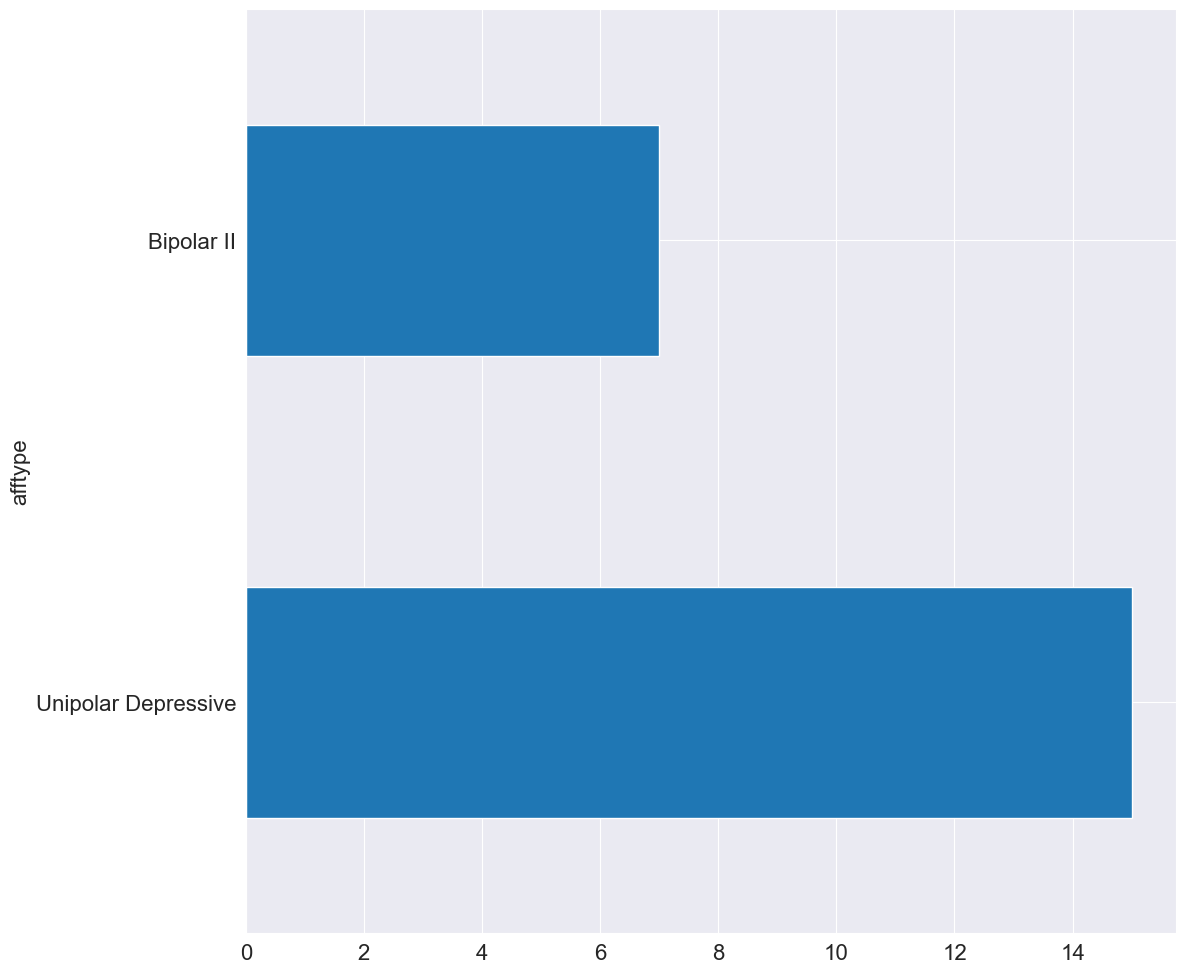

In [7]:
###Exploring the target variable
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(12,12))
counter = target["afftype"].value_counts()
counter.rename(index={1.0: "Bipolar II",
                       0.0: "Unipolar Depressive"},
               inplace=True
              )
ax.set_xlabel("# Cases", size=16)
counter.plot(kind="barh", ax=ax)


In [8]:
####Initializing the features and target variables
x, y = features, target

In [9]:
####Splitting the data into train and test sets
x_train, x_test, y_train, y_test = model_selection.train_test_split(x,
                                                                    y,
                                                                    test_size=0.3,
                                                                    random_state=80,
                                                                    stratify=target)

In [10]:
####Displaying train set
x_train

,days,gender,age,melanch,inpatient,edu,marriage,work,madrs1,madrs2,activity_mean,activity_std
7,5,2,27.0,NaN,2.0,13.0,1.0,2.0,20.0,16.0,316.545,503.483
15,16,1,47.0,2.0,2.0,13.0,1.0,2.0,13.0,17.0,338.069,424.913
18,13,1,32.0,1.0,1.0,8.0,1.0,2.0,27.0,25.0,171.471,220.950
8,13,2,47.0,NaN,2.0,8.0,1.0,2.0,26.0,26.0,289.151,348.722
13,14,1,62.0,2.0,2.0,8.0,2.0,2.0,28.0,19.0,205.845,262.523
1,18,2,42.0,2.0,2.0,8.0,2.0,2.0,24.0,11.0,153.673,330.808
16,13,1,52.0,2.0,2.0,8.0,1.0,2.0,17.0,15.0,147.850,211.517
5,7,1,37.0,2.0,2.0,8.0,1.0,2.0,18.0,15.0,361.821,382.775
2,13,1,47.0,2.0,2.0,8.0,2.0,2.0,24.0,25.0,265.300,399.881
10,14,1,47.0,2.0,2.0,8.0,1.0,2.0,24.0,24.0,300.669,369.657


In [11]:
####Training the XGBoost model
proportion_class = counter["Unipolar Depressive"]/counter["Bipolar II"]

params_xgb = {
    "n_estimators": 200,
    "max_depth": 8,
    "learning_rate": 0.05,
    "scale_pos_weight": proportion_class # to handle class imbalance
}
xgb = XGBClassifier(**params_xgb, use_label_encoder=True)
xgb.fit(x_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

Text(0.5, 1.0, 'Confusion Matrix (Train set)')

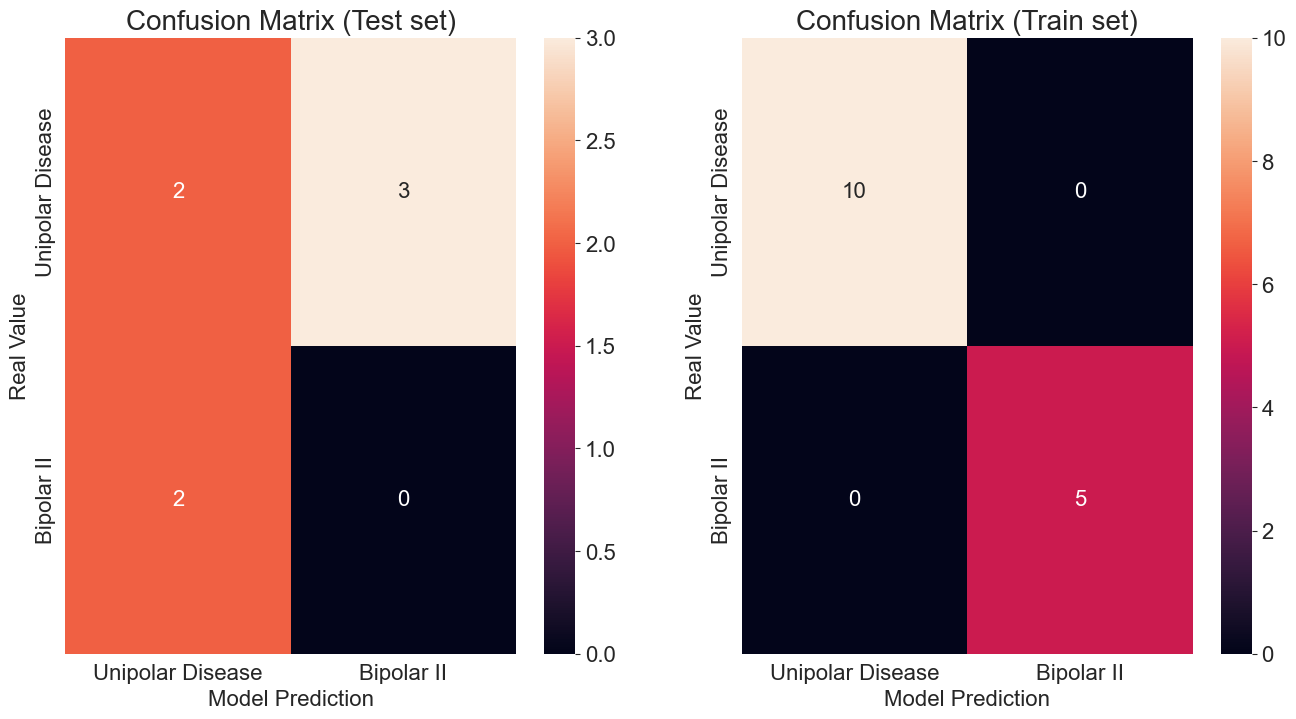

In [12]:
####Evaluating the model using confusion matrix
y_hat = xgb.predict(x_test)
cf = metrics.confusion_matrix(y_pred=y_hat, y_true=y_test)
cf_train = metrics.confusion_matrix(y_pred=xgb.predict(x_train), y_true=y_train)
names_df = [
    "Unipolar Disease",
    "Bipolar II"
]
cf_df = pd.DataFrame(data=cf, columns=names_df, index=names_df)
cf_train_df = pd.DataFrame(data=cf_train, columns=names_df, index=names_df)
fig, ax = plt.subplots(ncols=2, figsize=(16,8))

sns.heatmap(cf_df, fmt="d",annot=True, ax=ax[0])
ax[0].set_xlabel("Model Prediction", size=16)
ax[0].set_ylabel("Real Value", size=16)
ax[0].set_title("Confusion Matrix (Test set)", size=20)

sns.heatmap(cf_train_df, fmt="d",annot=True, ax=ax[1])
ax[1].set_xlabel("Model Prediction", size=16)
ax[1].set_ylabel("Real Value", size=16)
ax[1].set_title("Confusion Matrix (Train set)", size=20)

<div style="text-align: center; font-weight: bold; font-size: 100%">2.2. SHAP Values</div><br>

**Exploitation des SHAP Values pour interpréter le modèle.**

In [13]:
#Run if shap not installed
! pip install shap

In [14]:
#Importing shap for model explainability
import shap

In [15]:
explainer = shap.TreeExplainer(xgb, x, model_output = "raw")
shap_values = explainer.shap_values(x)

**Interprétabilité locale**

Deux graphes ont été utilisés pour interpréter le modèle: le force plot et le waterfall. Le force plot montre comment les variables poussent positivement ou négativement la prédiction d'une observation individuelle à partir de la moyenne. Le waterfall fait la même chose mais pour chaque variable et non de façon globale. Cela le rend plus lisible.

In [16]:
#Visuailizing waterfall plot for the patient 11
shap.initjs()
patient_index = 11
shap.force_plot(explainer.expected_value, shap_values[patient_index,:], x.iloc[patient_index,:])

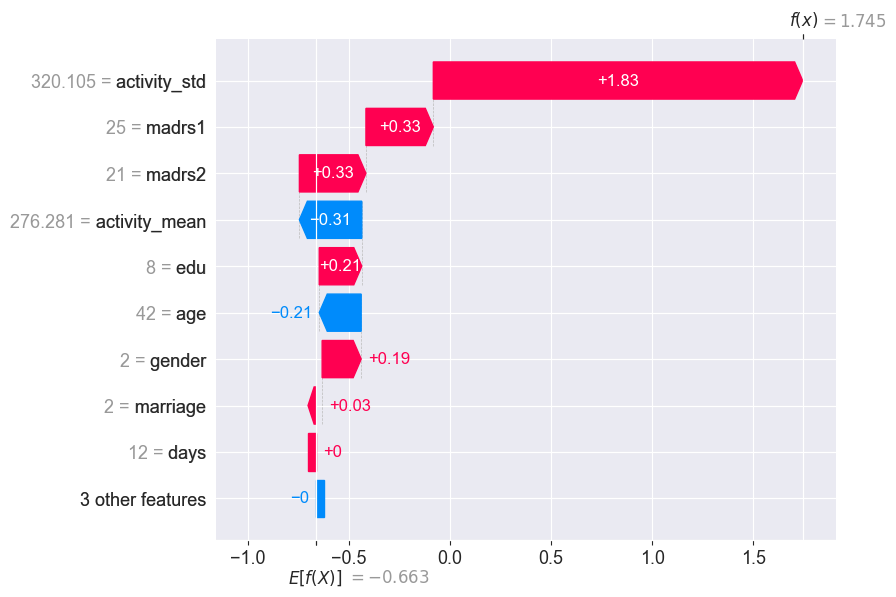

In [17]:
#Visuailizing waterfall plot for the same patient
shap.plots.waterfall(explainer(x)[patient_index])

Ces deux graphes nous disent la même chose. La variable qui influence plus les prédictions est activity_std. En effet, elle mesure la variabilité comportementale d'un individu. Et il s'agit d'un critère fondamental des troubles bipolaires. Les scores de dépression contribuent aussi assez à la prédiction individuelle du patient 11.

**Probabilité de prédiction**

In [18]:
#Dsplaying the real and predicted diagnosis for patient 2
patient_index = 2

# Patient real target value
diagnosis_map = {1.0: "Bipolar II",
                0.0: "Unipolar Depressive"}
print("-------Patient Real Diagnosis------")

print(y.replace(diagnosis_map).iloc[patient_index].values[0])
print("-------Patient Predicted Diagnosis------")
pred_class = xgb.predict(x.loc[patient_index:patient_index, :])[0]
if pred_class==0.0:
    pred_diagnosis = diagnosis_map[0.0]
    p1 = xgb.predict_proba(x.loc[patient_index:patient_index, :])[0][0]
    p1_round = round(p1,3)
else:
    pred_diagnosis = diagnosis_map[1.0]
    p1 = xgb.predict_proba(x.loc[patient_index:patient_index, :])[0][1]
    p1_round = round(p1,3)
print(f'Probability of being diagnosed with a {pred_diagnosis} \n{p1_round}')


-------Patient Real Diagnosis------
Unipolar Depressive
-------Patient Predicted Diagnosis------
Probability of being diagnosed with a Unipolar Depressive 
0.9330000281333923


**Interprétabilité globale**

Dans la sous-section de l'interprétabilité locale, nous avons conclu que activity_std influence plus la prédiction du patient 11. Nous allons à partir du graphe beeswarm qui nous donne une vue globale, pouvoir généraliser cette remarque.

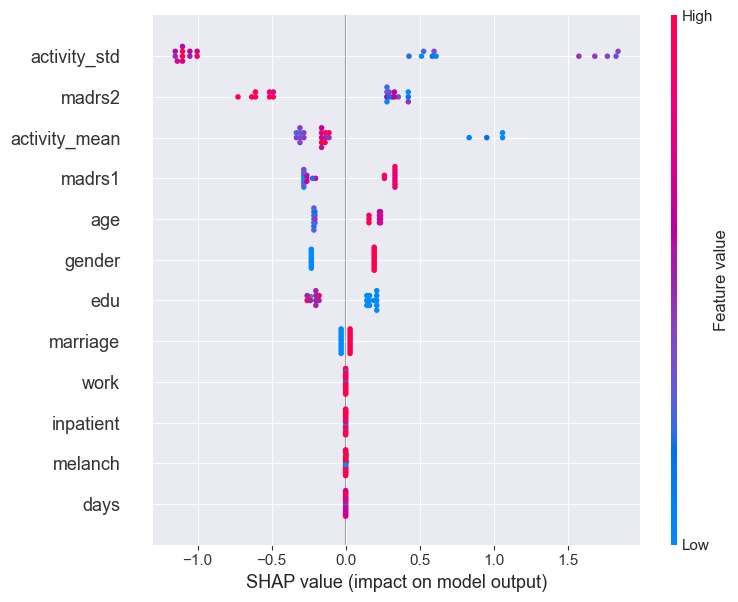

In [19]:
shap.summary_plot(shap_values, x, show=False)

plt.savefig("shap_summary_plot.png", bbox_inches="tight")

**Conclusion 1:**

L'interprétabilité globale confirme que la variables activity_std contribue plus aux prédictions individuelles. Les variables de mesure de dépression, l'âge, le genre et le nombre d'années d'éducation ne sont pas négligeables. Les autres variables ne contribuent pas du tout aux prédictions. L'utilisation de la méthode de SHAP Values s'est avérée très bénéfique car elle permet d'expliquer les facteurs qui expliquent les troubles bipolaires. Afin de confirmer la fiabilité de cette méthode, nous avons appliqué le même processing à un autre jeu de données.

<div style="text-align: center; font-weight: bold; font-size: 125%">3. Étude de cas: La dépression chez les étudiants</div><br>

Pour tester la méthode de SHAP Values, nous avons utilisé un jeu de données qui a été construit en réalisant des enquêtes auprès de 100000 étudiants. L'enquête est axée sur leurs habitudes de vie, leurs performances académiques et leur bien-être mental. Chaque ligne représente un étudiant unique avec des détails démographiques, des habitudes de vie, des performances académiques. Le but de cette enquête est d'établir si un étudiant est en dépression ou en bonne santé.

Dans la suite, ce que nous essayerons de faire est d'expliquer les facteurs qui contribuent à la dépression d'un étudiant.

Les variables que nous aurons à manipuler sont décrites comme ci-dessous:

- **student_ID** : l'ID d'un étudiant
- **gender** : sexe de l'étudiant (0 = homme, 1 = femme)
- **age** : âge de l'étudiant
- **department** : le domaine d'étude
- **cgpa** : moyenne cumulative des notes
- **sleep_duration** : nombre moyen d'heures de sommeil par nuit
- **study_hours** : nombre moyen d'heures d'étude par jour
- **social_media_hours** : temps moyen passé sur les réseaux sociaux par jour (en heures)
- **physical_activity** : fréquence de l'exercice physique par semaine
- **stress_level** : niveau de stress donné par l'étudiant lui-même
- **depression** : étudiant probablement dépressif ou en bonne santé

**Source**

[Student Depression & Lifestyle (100k Data) sur Kaggle](https://www.kaggle.com/datasets/aldinwhyudii/student-depression-and-lifestyle-100k-data)


<div style="text-align: center; font-weight: bold; font-size: 100%">3.1. Pipeline d'apprentissage</div><br>

In [20]:
! pip install kagglehub

In [21]:
####Data importation
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aldinwhyudii/student-depression-and-lifestyle-100k-data")

print("Path to dataset files:", path)

dataset = pd.read_csv(os.path.join(path, "student_lifestyle_100k.csv"))

dataset

Path to dataset files: /Users/yayraleakibode/.cache/kagglehub/datasets/aldinwhyudii/student-depression-and-lifestyle-100k-data/versions/1


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False
...,...,...,...,...,...,...,...,...,...,...,...
99995,100996,24,Female,Medical,2.02,7.0,0.6,1.4,66,4,False
99996,100997,24,Male,Arts,2.33,5.0,3.6,5.2,103,3,False
99997,100998,24,Female,Engineering,2.23,6.5,5.8,4.1,61,5,False
99998,100999,19,Male,Engineering,3.61,6.1,4.8,4.9,116,4,False


In [22]:
####Selecting a subset of observations for the model
sub_dataset = dataset.sample(n=100, random_state=80)
sub_dataset=sub_dataset.reset_index(drop=True)

In [23]:
####Data preprocessing
features = sub_dataset.drop(columns=["Depression"])
target = sub_dataset["Depression"]

gender_map = {"Male": 0, "Female": 1}
features["Gender"] = features["Gender"].map(gender_map)

department_map = {'Science': 0, 'Engineering': 1, 'Medical': 2, 'Arts': 3, 'Business': 4}
features["Department"] = features["Department"].map(department_map)

target_map = {False: 0, True: 1}
target = target.map(target_map)


<Axes: ylabel='Depression'>

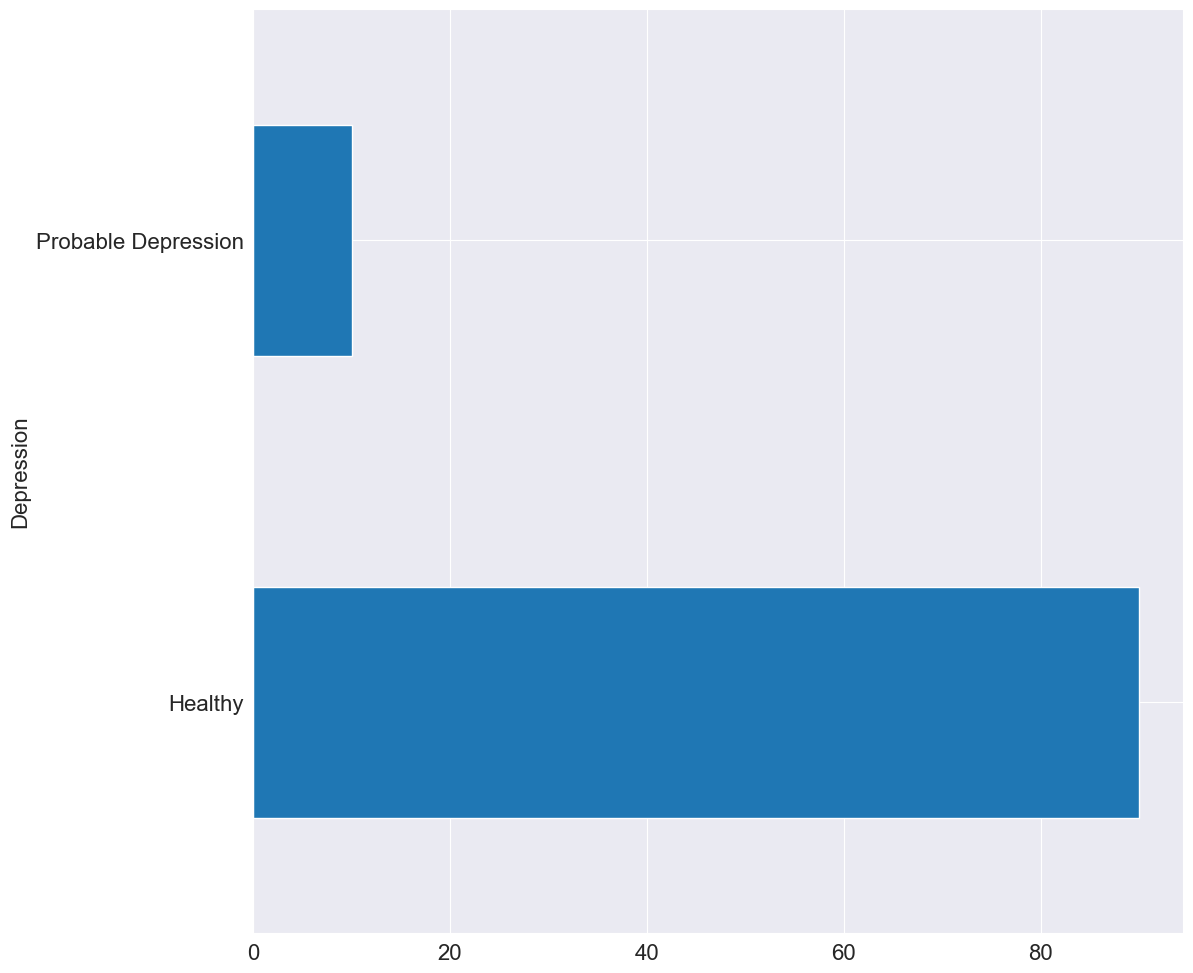

In [24]:
###Exploring the target variable
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(12,12))
counter = target.value_counts()
counter.rename(index={1.0: "Probable Depression",
                       0.0: "Healthy"},
               inplace=True
              )
ax.set_xlabel("# Cases", size=16)
counter.plot(kind="barh", ax=ax)

In [25]:
####Splitting the data into train and test sets
x_train, x_test, y_train, y_test = model_selection.train_test_split(features,
                                                                    target,
                                                                    test_size=0.3,
                                                                    random_state=80,
                                                                    stratify=target)

In [26]:
####Training the XGBoost model
proportion_class = counter["Healthy"]/counter["Probable Depression"]

params_xgb = {
    "n_estimators": 200,
    "max_depth": 8,
    "learning_rate": 0.05,
    "scale_pos_weight": proportion_class # to handle class imbalance
}
xgb = XGBClassifier(**params_xgb, use_label_encoder=True)
xgb.fit(x_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

Text(0.5, 1.0, 'Confusion Matrix (Train set)')

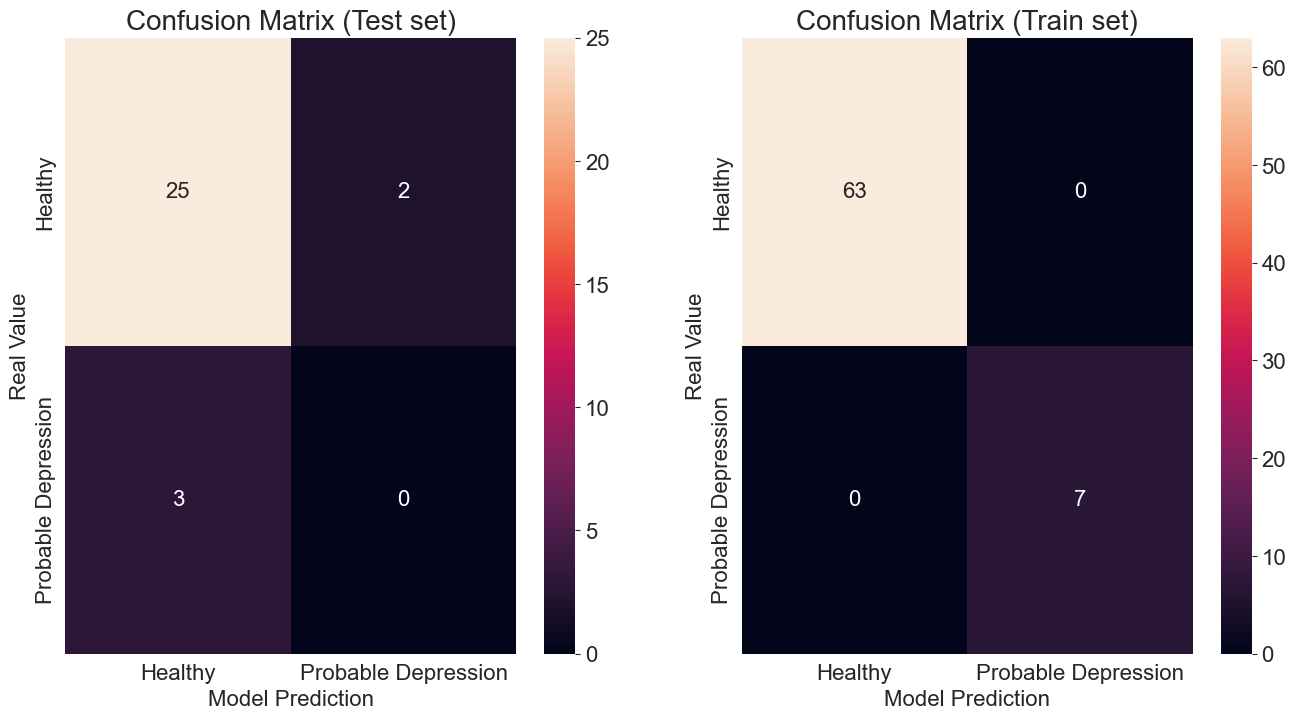

In [27]:
####Evaluating the model using confusion matrix
y_hat = xgb.predict(x_test)
cf = metrics.confusion_matrix(y_pred=y_hat, y_true=y_test)
cf_train = metrics.confusion_matrix(y_pred=xgb.predict(x_train), y_true=y_train)
names_df = [
    "Healthy",
    "Probable Depression"
]
cf_df = pd.DataFrame(data=cf, columns=names_df, index=names_df)
cf_train_df = pd.DataFrame(data=cf_train, columns=names_df, index=names_df)
fig, ax = plt.subplots(ncols=2, figsize=(16,8))

sns.heatmap(cf_df, fmt="d",annot=True, ax=ax[0])
ax[0].set_xlabel("Model Prediction", size=16)
ax[0].set_ylabel("Real Value", size=16)
ax[0].set_title("Confusion Matrix (Test set)", size=20)

sns.heatmap(cf_train_df, fmt="d",annot=True, ax=ax[1])
ax[1].set_xlabel("Model Prediction", size=16)
ax[1].set_ylabel("Real Value", size=16)
ax[1].set_title("Confusion Matrix (Train set)", size=20)

<div style="text-align: center; font-weight: bold; font-size: 100%">3.2. SHAP Values</div><br>

In [28]:
explainer = shap.TreeExplainer(xgb, features, model_output = "raw")
shap_values = explainer.shap_values(features)

**Interprétabilité locale**

In [29]:
####Visuailizing waterfall plot for a depression patient
shap.initjs()
patient_index = target[target==1].index[0]
shap.force_plot(explainer.expected_value, shap_values[patient_index,:], features.iloc[patient_index,:])

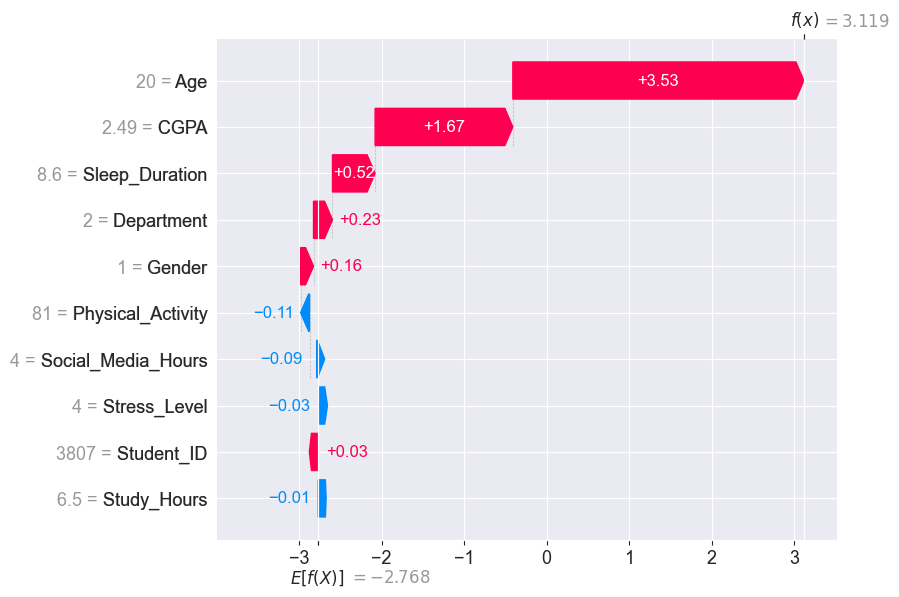

In [30]:
####Visuailizing waterfall plot for the patient 11
shap.plots.waterfall(explainer(features)[patient_index])

**Interprétabilité globale**

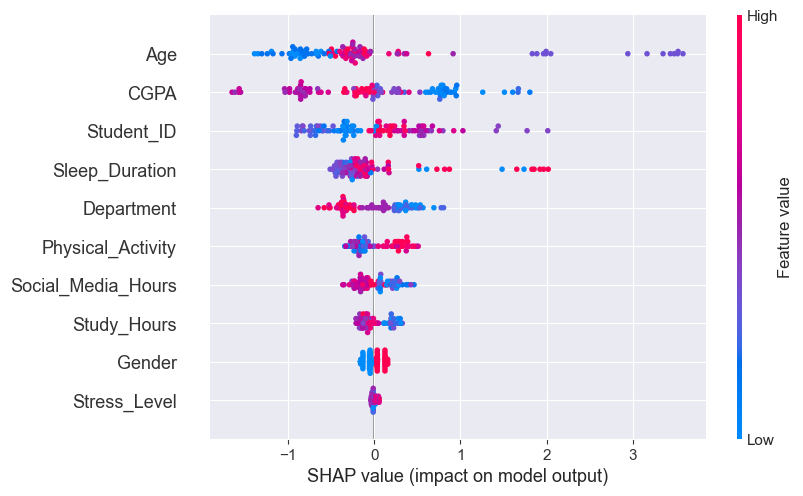

In [31]:
####Visualizing the summary plot for the model
shap.plots.beeswarm(explainer(features))

**Conclusion 2:**

Tant au niveau global, qu'au niveau local, l'âge contribue énormément à la prédiction de la dépression chez les étudiants. L'explication rationnelle n'est pas évidente comme ce fut le cas pour les données sur les troubles bipolaires. Ensuite il y a la moyenne cumulée qui contribue assez aussi. Ce qui est évident, selon qu'un étudiant a de bonnes notes ou pas, il est exposé ou pas à la dépression. L'interprétation du modèle avec les SHAP Values sur ce jeu de données est très bénéfique. De fait, l'âge qui contribue plus à la dépression d'un étudiant que l'activité physique par semaine, ou encore le temps passé sur les réseaux sociaux montre que le modèle XGBoost n'est peut être pas le bon modèle adapté au ce contexte. 

**Conclusion générale:**

De façon générale l'analyse du modèle XGBoost sur ces deux jeux de de données avec la méthode de SHAP Values s'est avérée très intéressante. Cette dernière nous permet de comprendre quelles variables contribuent aux prédictions globales. Elle nous donne également une vue globale. Le travail effectué confirme encore une fois l'importance de l'explicabilité et de l'interprétabilité des modèles d'apprentissage automatique, et surtout l'importance et l'efficacité des valeurs de Shapley.